# Declarative System Descriptions

So far, every system was assembled in Python code. SysSimX can also build and run a system from a **declarative description** in YAML or JSON. This is useful when you want to:

- separate the system *structure* from the component *implementations*,
- run parameter or algorithm variations by editing a config file instead of code,
- launch simulations from the command line or from CI without writing a script,
- share a reproducible system setup as a single file.

This tutorial rebuilds the source-integrator system from the {doc}`/01_getting_started/02_quickstart` declaratively, runs it via `build_system` / `run_from_config`, and finishes with the `syssimx` command-line interface.

## Put the Components in an Importable Module

The loader references component classes by their import path (`module.path:ClassName`), so the classes must live in a normal Python module rather than in a notebook. Any installed `CoSimComponent` subclass works without registration — including `FMUComponent`, `OpenSimComponent`, and the NGSolve transient structural-dynamics `FEMComponent` base.

We write the two quickstart components to a module next to this notebook:

In [1]:
%%writefile quickstart_components.py
"""Components for the declarative-systems tutorial."""

from syssimx import CoSimComponent
from syssimx.core import PortSpec, PortType


class LinearSource(CoSimComponent):
    """Linear source: y(t) = a * t + b."""

    def __init__(self, name: str, a: float = 1.0, b: float = 0.0):
        super().__init__(name, group="Source")
        self.a = a
        self.b = b
        self.output_specs.update({
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names=None):
        self.outputs["y"].set(self.a * t + self.b, t)


class Integrator(CoSimComponent):
    """Integrator with explicit Euler stepping."""

    def __init__(self, name: str, x0: float = 0.0):
        super().__init__(name, group="Integrator")
        self.x0 = x0
        self.input_specs.update({
            "u": PortSpec(name="u", type=PortType.REAL, direction="in")
        })
        self.output_specs.update({
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        u = self.inputs["u"].get()
        self.x += u * dt

    def _update_output_states(self, t: float | None = None, event_names=None):
        self.outputs["y"].set(self.x, t)

Overwriting quickstart_components.py


## Write the System Description

A description has up to five sections:

| Section | Purpose |
|---|---|
| `system` | System name |
| `components` | One entry per component: `name`, `class` (`module:ClassName`), optional constructor `args` and post-construction `parameters` |
| `connections` | Signal connections, written as `"Component.port"` strings or explicit `{component: ..., port: ...}` mappings |
| `event_connections` | Optional event routing for hybrid systems |
| `algorithm` | Master algorithm: `jacobi`, `gauss_seidel` (default), `hybrid`, or `ijcsa` |
| `run` | Default run settings (`t0`, `tf`, `dt`) used by `run_from_config` and the CLI |

JSON files with the same structure are equally supported (selected by the `.json` file extension).

In [2]:
%%writefile declarative_quickstart.yaml
system:
  name: QuickstartSystem

components:
  - name: LinearSource
    class: "quickstart_components:LinearSource"
    args: {a: 1.0, b: 0.0}
  - name: Integrator
    class: "quickstart_components:Integrator"
    args: {x0: 0.0}

connections:
  - src: LinearSource.y
    dst: Integrator.u

algorithm:
  type: gauss_seidel

run:
  t0: 0.0
  tf: 5.0
  dt: 0.1

Overwriting declarative_quickstart.yaml


## Build and Inspect the System

`build_system` assembles (but does not initialize) a `System` from the description. Invalid descriptions raise a `ConfigError` with a message pointing at the offending entry. The structural report shows what was assembled:

In [3]:
from syssimx.system import build_system

system = build_system("declarative_quickstart.yaml")
print(system.describe())

System 'QuickstartSystem'
  Algorithm: GaussSeidelAlgorithm
  Initialized: False
  Components (2):
    - LinearSource (LinearSource): 0 in / 1 out
    - Integrator (Integrator): 1 in / 1 out
  Connections (1):
    - LinearSource.y -> Integrator.u
  Execution order: not yet computed (call initialize())
  Algebraic loops: none detected


## Run From the Description

`run_from_config` assembles, initializes, and runs the system in one call, using the `run` section for the time settings, and returns the familiar `SimulationResult`. Individual settings can be overridden as keyword arguments, e.g. `run_from_config("declarative_quickstart.yaml", tf=10.0)`.

In [4]:
from syssimx.system import run_from_config

result = run_from_config("declarative_quickstart.yaml")
result

<SimulationResult 'QuickstartSystem' t=[0.0, 5.0] dt=0.1 components=2 algorithm=GaussSeidelAlgorithm>

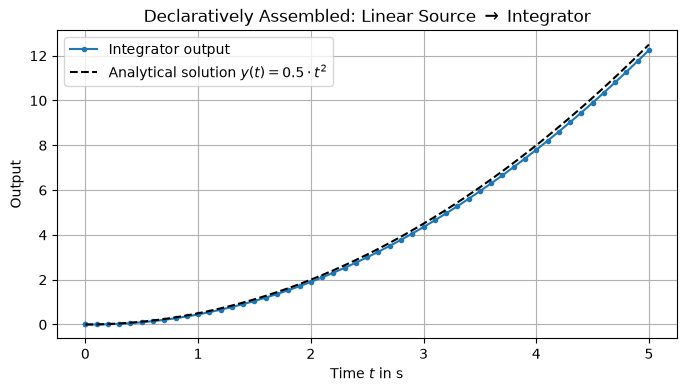

In [5]:
import matplotlib.pyplot as plt
import numpy as np

t_vals, data = result["Integrator"]
t_an = np.linspace(result.t0, result.tf, 500)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, data["y"], label="Integrator output", marker=".")
plt.plot(t_an, 0.5 * t_an**2, label=r"Analytical solution $y(t) = 0.5 \cdot t^2$", color="black", linestyle="--")
plt.xlabel(r"Time $t$ in s")
plt.ylabel("Output")
plt.title("Declaratively Assembled: Linear Source $\\to$ Integrator")
plt.grid()
plt.legend()
plt.show()

## The Command-Line Interface

Installing SysSimX also installs the `syssimx` console script, which works directly on description files:

```bash
syssimx describe declarative_quickstart.yaml            # print the structural report
syssimx run declarative_quickstart.yaml                 # run with the file's run settings
syssimx run declarative_quickstart.yaml --tf 10 --dt 0.01   # override run settings
syssimx run declarative_quickstart.yaml -o results.csv  # export results (tidy long format)
```

The CLI makes modules next to the description file (and in the current directory) importable, so `quickstart_components.py` is found automatically. Here we invoke it as a subprocess so the output is captured in the notebook:

In [6]:
import subprocess
import sys

proc = subprocess.run(
    [sys.executable, "-m", "syssimx.cli", "run", "declarative_quickstart.yaml",
     "-o", "declarative_results.csv", "--quiet"],
    capture_output=True,
    text=True,
    check=True,
)
print(proc.stdout)

Completed 'QuickstartSystem': t in [0.0, 5.0] s, dt = 0.1 s, algorithm = GaussSeidelAlgorithm, wall time = 0.000 s
Results written to declarative_results.csv



## Next Steps

- The `algorithm` section accepts any of the master algorithms compared in {doc}`01_comparing_algorithms`.
- `event_connections` route events between components in hybrid systems — see {doc}`03_simple_hybrid_system`.
- Descriptions work just as well with the tool adapters (`FMUComponent`, `OpenSimComponent`, and the structural-dynamics `FEMComponent`) — see the tool-integration tutorials, starting with {doc}`/04_tool_integration/01_modelica/index`.